
# Olist Reviews — Refactored Pipeline + EDA + SHAP

This notebook:
- Fixes wide one-hot for `customer_state` by mapping **state → region** and **label-encoding** the region.
- Uses **Target Encoding** for high-cardinality `product_category_name` and **One-Hot** for low-cardinality `order_status`.
- Trains a simple Keras model on transformed features using a leakage-safe pipeline.
- Restores key **EDA** visuals from your previous script and adds **region-level** plots.
- Adds **SHAP** explanations with DeepExplainer (for Keras), with a fallback path, and an optional RandomForest surrogate for fast Tree SHAP.



> **Dependencies**: pandas, numpy, scikit-learn, category-encoders, tensorflow, shap
>
> If needed:
```bash
# !pip install pandas numpy scikit-learn category-encoders tensorflow shap
```


In [1]:
!pip install pandas numpy scikit-learn category-encoders tensorflow shap

## 1) Imports & Settings

In [2]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import category_encoders as ce

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120})


## 2) Constants & Helpers

In [3]:

DATA_FILES = {
    "products": "olist_products_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
}

STATE_TO_REGION = {
    # North
    "AC":"North","AP":"North","AM":"North","PA":"North","RO":"North","RR":"North","TO":"North",
    # Northeast
    "AL":"Northeast","BA":"Northeast","CE":"Northeast","MA":"Northeast","PB":"Northeast","PE":"Northeast",
    "PI":"Northeast","RN":"Northeast","SE":"Northeast",
    # Central-West
    "DF":"Central-West","GO":"Central-West","MT":"Central-West","MS":"Central-West",
    # Southeast
    "ES":"Southeast","MG":"Southeast","RJ":"Southeast","SP":"Southeast",
    # South
    "PR":"South","RS":"South","SC":"South",
}
REGION_ORDER = ["North","Northeast","Central-West","Southeast","South"]

def map_state_to_region(s):
    return STATE_TO_REGION.get(s, "Unknown")

def load_data(data_dir: Path = Path('.')) -> dict:
    dfs = {}
    for key, fname in DATA_FILES.items():
        fpath = data_dir / fname
        if not fpath.exists():
            raise FileNotFoundError(f"Missing required CSV: {fpath}")
        dfs[key] = pd.read_csv(fpath)
    return dfs


## 3) Clean & Merge

In [4]:

def clean_and_merge(d: dict) -> pd.DataFrame:
    products  = d['products'].copy()
    reviews   = d['reviews'].copy()
    items     = d['order_items'].copy()
    customers = d['customers'].copy()
    orders    = d['orders'].copy()

    products = products.dropna(subset=['product_name_lenght', 'product_weight_g'])

    # Review dates
    reviews = reviews.drop(columns=[c for c in ['review_comment_title','review_comment_message'] if c in reviews.columns])
    for col in ['review_creation_date','review_answer_timestamp']:
        if col in reviews.columns:
            reviews[col] = pd.to_datetime(reviews[col])

    for col in ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
                'order_delivered_customer_date','order_estimated_delivery_date']:
        if col in orders.columns:
            orders[col] = pd.to_datetime(orders[col])

    mask_bad = (orders['order_status']=='delivered') & (orders['order_delivered_customer_date'].isnull())
    orders = orders.loc[~mask_bad].copy()

    orders['delivery_delay'] = (orders['order_delivered_customer_date'] -
                                orders['order_estimated_delivery_date'])

    if 'shipping_limit_date' in items.columns:
        items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

    merged = (
        items.merge(products, on='product_id', how='inner')
             .merge(orders, on='order_id', how='inner')
             .merge(customers, on='customer_id', how='left')
             .merge(reviews, on='order_id', how='inner')
    )

    merged['sentiment_group'] = np.select(
        [merged['review_score'] <= 2, merged['review_score'] == 3, merged['review_score'] >= 4],
        ['Negative','Neutral','Positive'],
        default='Unknown'
    )
    return merged


## 4) Feature Selection & Preparation

In [5]:

NUM_COLS = ['product_description_lenght','product_photos_qty','price','freight_value']
DELAY_COL_ORIG = 'delivery_delay'
DELAY_COL_DAYS = 'delivery_delay_days'
CAT_HIGH_CARD = ['product_category_name']
CAT_LOW_CARD  = ['order_status']
STATE_COL     = 'customer_state'

def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data[DELAY_COL_DAYS] = data[DELAY_COL_ORIG].dt.days
    data[DELAY_COL_DAYS] = data[DELAY_COL_DAYS].fillna(data[DELAY_COL_DAYS].median())
    data['customer_region'] = data[STATE_COL].map(map_state_to_region)
    keep_cols = NUM_COLS + [DELAY_COL_DAYS] + CAT_LOW_CARD + CAT_HIGH_CARD + ['customer_region','sentiment_group']
    data = data[keep_cols].copy()
    data = data[data['customer_region']!='Unknown'].copy()
    return data


## 5) Preprocessing Pipeline

In [6]:

from sklearn.preprocessing import FunctionTransformer

def build_preprocess_pipeline():
    num_pipe = Pipeline(steps=[('scaler', StandardScaler())])
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    target_enc = ce.TargetEncoder(cols=CAT_HIGH_CARD, smoothing=0.3)

    region_to_int = {r:i for i, r in enumerate(REGION_ORDER)}
    def _encode_region(X):
        arr = np.ravel(np.asarray(X))
        s = pd.Series(arr)
        return s.map(region_to_int).fillna(-1).to_frame()

    region_label_enc = FunctionTransformer(_encode_region, validate=False, feature_names_out='one-to-one')

    preprocess = ColumnTransformer(
        transformers=[
            ('num', num_pipe, NUM_COLS + [DELAY_COL_DAYS]),
            ('ohe_low', ohe, CAT_LOW_CARD),
            ('target_high', target_enc, CAT_HIGH_CARD),
            ('region_label', region_label_enc, ['customer_region']),
        ],
        remainder='drop'
    )
    return preprocess


## 6) Model (Keras)

In [7]:

def build_ffnn(input_dim: int, num_classes: int = 3) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.15),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


## 7) Train/Test Split → Fit Encoders & Model

In [8]:

def train_pipeline(mergeddf: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    data = prepare_features(mergeddf)
    X = data.drop(columns=['sentiment_group'])
    y = data['sentiment_group'].copy()
    target_classes = ['Negative','Neutral','Positive']
    y = pd.Categorical(y, categories=target_classes, ordered=False)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    preprocess = build_preprocess_pipeline()
    X_train_t = preprocess.fit_transform(X_train, y_train)
    X_test_t  = preprocess.transform(X_test)

    input_dim = X_train_t.shape[1]
    num_classes = len(target_classes)
    y_train_oh = keras.utils.to_categorical(y_train.codes, num_classes=num_classes)
    y_test_oh  = keras.utils.to_categorical(y_test.codes,  num_classes=num_classes)

    model = build_ffnn(input_dim=input_dim, num_classes=num_classes)
    history = model.fit(
        X_train_t, y_train_oh,
        validation_data=(X_test_t, y_test_oh),
        epochs=15, batch_size=256, verbose=1
    )

    return {
        'preprocess': preprocess,
        'model': model,
        'X_train': X_train, 'X_test': X_test,
        'X_train_t': X_train_t, 'X_test_t': X_test_t,
        'y_train': y_train, 'y_test': y_test,
        'history': history,
        'target_classes': target_classes,
    }


## 8) Train & Evaluate

Epoch 1/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7413 - loss: 0.7219 - val_accuracy: 0.7946 - val_loss: 0.6460
Epoch 2/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7904 - loss: 0.6523 - val_accuracy: 0.7941 - val_loss: 0.6400
Epoch 3/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7944 - loss: 0.6406 - val_accuracy: 0.7939 - val_loss: 0.6379
Epoch 4/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7960 - loss: 0.6367 - val_accuracy: 0.7944 - val_loss: 0.6357
Epoch 5/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7953 - loss: 0.6383 - val_accuracy: 0.7951 - val_loss: 0.6352
Epoch 6/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7961 - loss: 0.6365 - val_accuracy: 0.7955 - val_loss: 0.6369
Epoch 7/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7954 - loss: 0.6372 - val_accuracy: 0.7954 - val_loss: 0.6349
Epoch 8/15
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7935 - loss: 0.6390 - val_accura

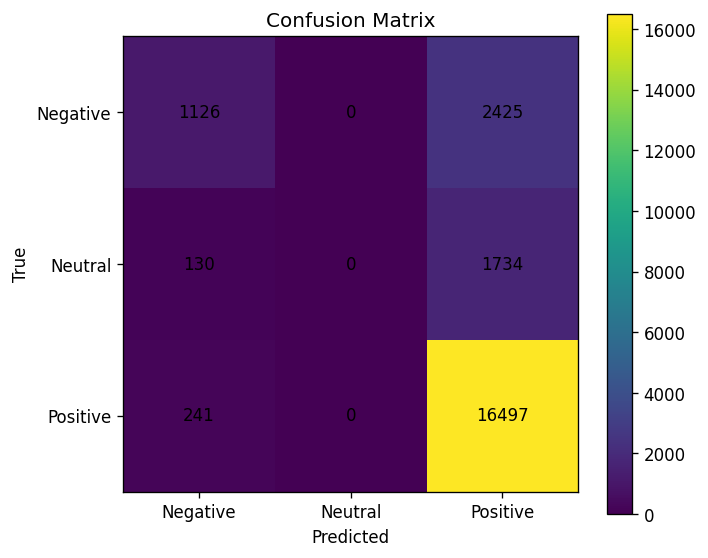

In [9]:

dfs = load_data(Path('.'))
mergeddf = clean_and_merge(dfs)
trained = train_pipeline(mergeddf, test_size=0.2, random_state=42)

# Basic eval
probs = trained['model'].predict(trained['X_test_t'], verbose=0)
y_pred_idx = probs.argmax(axis=1)
y_true_idx = trained['y_test'].codes
print(classification_report(y_true_idx, y_pred_idx, target_names=trained['target_classes']))

# Confusion matrix (matplotlib, no seaborn)
cm = confusion_matrix(y_true_idx, y_pred_idx)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)
ax.set_xticks(range(len(trained['target_classes'])))
ax.set_yticks(range(len(trained['target_classes'])))
ax.set_xticklabels(trained['target_classes'])
ax.set_yticklabels(trained['target_classes'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


## 9) EDA — Prep

In [10]:

eda_df = mergeddf.copy()
eda_df['customer_region'] = eda_df['customer_state'].map(map_state_to_region)
eda_df = eda_df[eda_df['customer_region'].isin(REGION_ORDER)].copy()
eda_df['delivery_delay_days'] = eda_df['delivery_delay'].dt.days


### Q1) Highest Avg Review Score — Top Category per Region

,customer_region,product_category_name,avg_review_score,review_count
0,Central-West,cool_stuff,4.142292,253
1,North,beleza_saude,3.910798,213
2,Northeast,cool_stuff,4.054321,405
3,South,perfumaria,4.296471,425
4,Southeast,livros_interesse_geral,4.466667,345


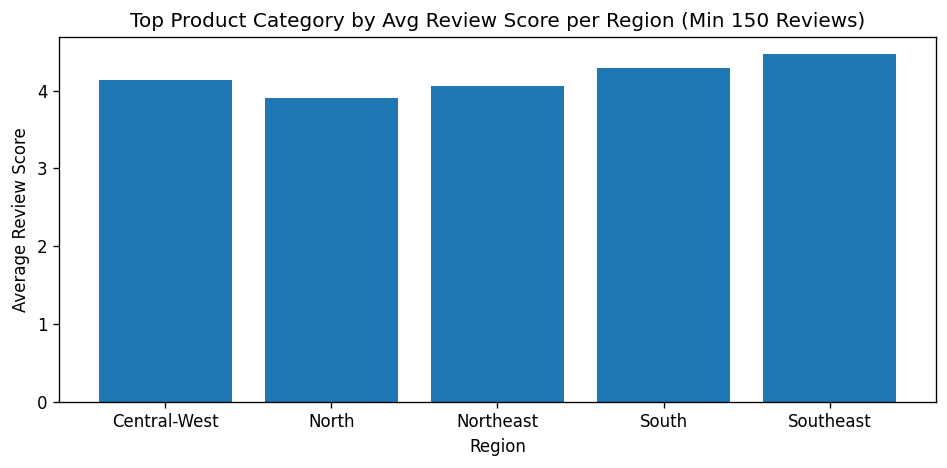

In [11]:

avg_scores_r = (eda_df
    .groupby(['customer_region','product_category_name'], dropna=False)['review_score']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'avg_review_score','count':'review_count'}))

min_reviews_threshold_region = 150
filtered_r = avg_scores_r[avg_scores_r['review_count'] >= min_reviews_threshold_region].copy()

idxr = filtered_r.groupby('customer_region')['avg_review_score'].idxmax()
top_categories_region = filtered_r.loc[idxr].sort_values('customer_region').reset_index(drop=True)
display(top_categories_region)

plt.figure(figsize=(8,4))
plt.bar(top_categories_region['customer_region'], top_categories_region['avg_review_score'])
plt.title(f'Top Product Category by Avg Review Score per Region (Min {min_reviews_threshold_region} Reviews)')
plt.ylabel('Average Review Score'); plt.xlabel('Region')
plt.tight_layout(); plt.show()


### Q2) Delivery Delay vs Review Sentiment

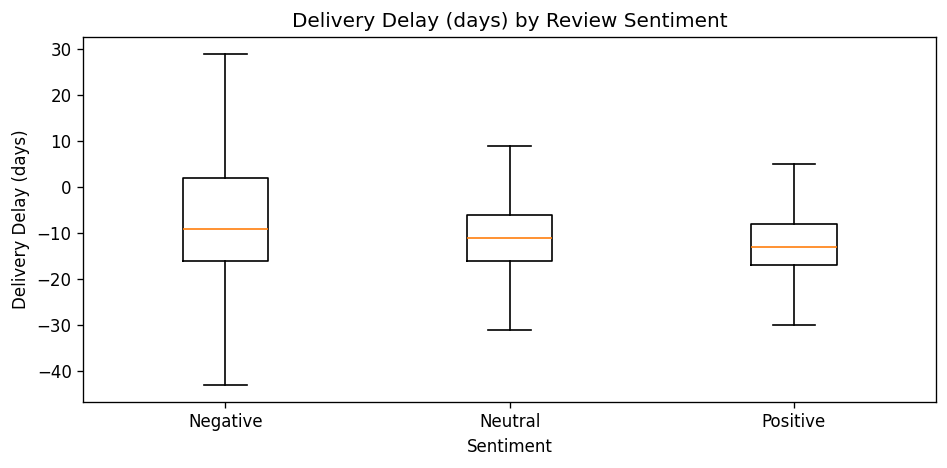

In [12]:

plot_df = eda_df[['delivery_delay_days','sentiment_group']].dropna()
order = ['Negative','Neutral','Positive']
plot_df['sentiment_group'] = pd.Categorical(plot_df['sentiment_group'], categories=order, ordered=True)
data_by_class = [plot_df.loc[plot_df['sentiment_group'] == c, 'delivery_delay_days'].values for c in order]

plt.figure(figsize=(8,4))
plt.boxplot(data_by_class, labels=order, showfliers=False)
plt.title('Delivery Delay (days) by Review Sentiment')
plt.xlabel('Sentiment'); plt.ylabel('Delivery Delay (days)')
plt.tight_layout(); plt.show()


### Q3) Regions with Highest Proportion of Negative Reviews

,customer_region,negative_share
0,North,0.183491
1,Northeast,0.197903
2,Central-West,0.164129
3,Southeast,0.155806
4,South,0.153145


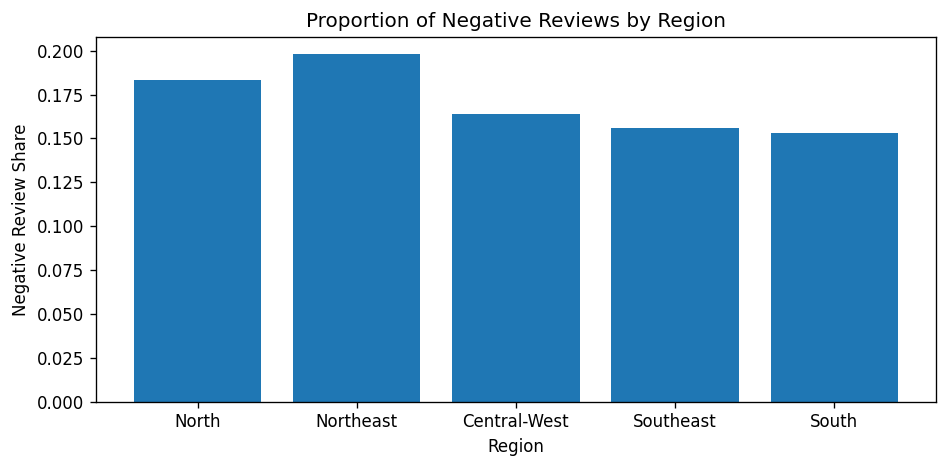

In [13]:

neg_share = (eda_df.assign(is_neg=(eda_df['sentiment_group']=='Negative').astype(int))
             .groupby('customer_region')['is_neg']
             .mean()
             .reindex(REGION_ORDER))

neg_share_df = neg_share.reset_index().rename(columns={'is_neg':'negative_share'})
display(neg_share_df)

plt.figure(figsize=(8,4))
plt.bar(neg_share.index, neg_share.values)
plt.title('Proportion of Negative Reviews by Region'); plt.xlabel('Region'); plt.ylabel('Negative Review Share')
plt.tight_layout(); plt.show()


### (Restored) Top Product Category by State

,customer_state,product_category_name,avg_review_score,review_count
0,BA,informatica_acessorios,3.949612,258
1,CE,beleza_saude,3.854545,165
2,DF,esporte_lazer,4.132743,226
3,ES,esporte_lazer,4.179191,173
4,GO,esporte_lazer,4.144578,166
5,MG,malas_acessorios,4.426230,183
6,PE,beleza_saude,4.054852,237
7,PR,perfumaria,4.392157,153
8,RJ,beleza_saude,4.063208,1060
9,RS,perfumaria,4.350649,154


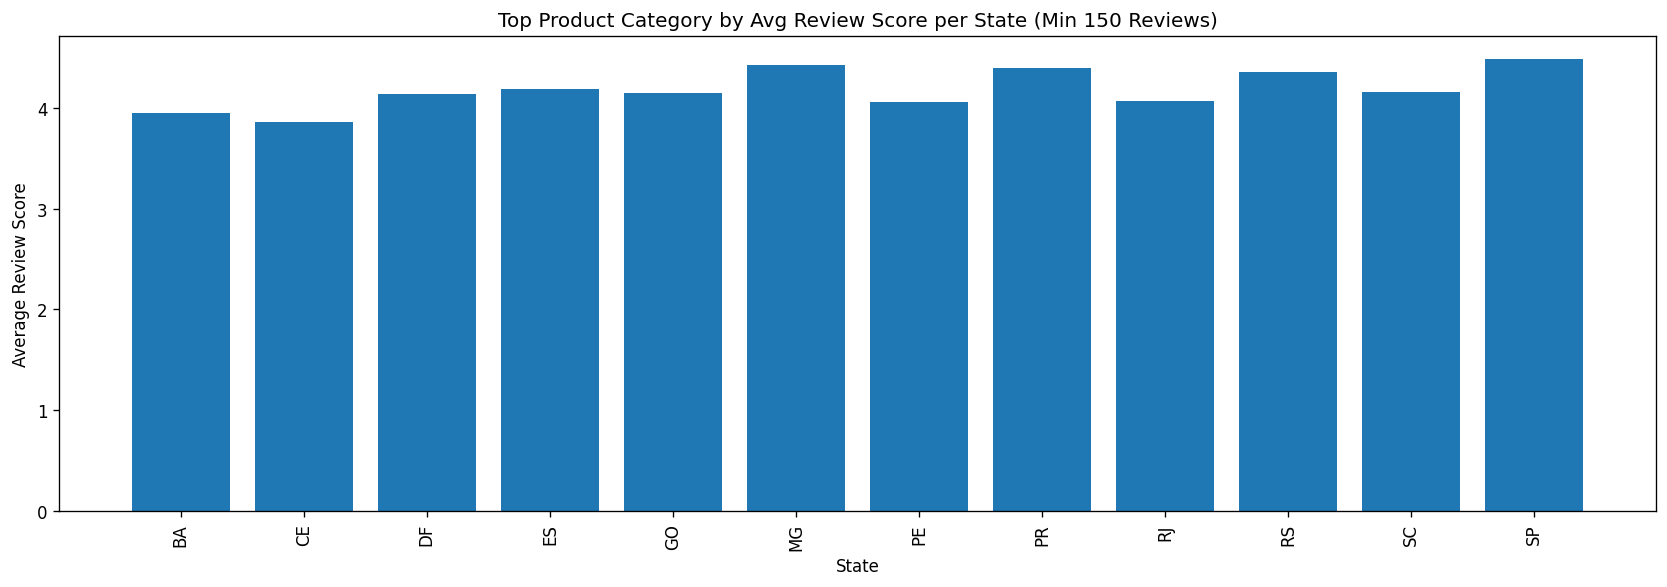

In [14]:

min_reviews_threshold = 150
avg_scores = (eda_df
    .groupby(['customer_state','product_category_name'], dropna=False)['review_score']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'avg_review_score','count':'review_count'}))

filtered_scores = avg_scores[avg_scores['review_count'] >= min_reviews_threshold].copy()

if not filtered_scores.empty:
    idx = filtered_scores.groupby('customer_state')['avg_review_score'].idxmax()
    top_categories_state = filtered_scores.loc[idx].sort_values('customer_state').reset_index(drop=True)
    display(top_categories_state)

    plt.figure(figsize=(14,5))
    plt.bar(range(len(top_categories_state)), top_categories_state['avg_review_score'])
    plt.xticks(range(len(top_categories_state)), top_categories_state['customer_state'], rotation=90)
    plt.title(f'Top Product Category by Avg Review Score per State (Min {min_reviews_threshold} Reviews)')
    plt.ylabel('Average Review Score'); plt.xlabel('State')
    plt.tight_layout(); plt.show()
else:
    print("No state/category meets the minimum review threshold.")


### (Restored) Review Score vs Delivery Delay — Scatter

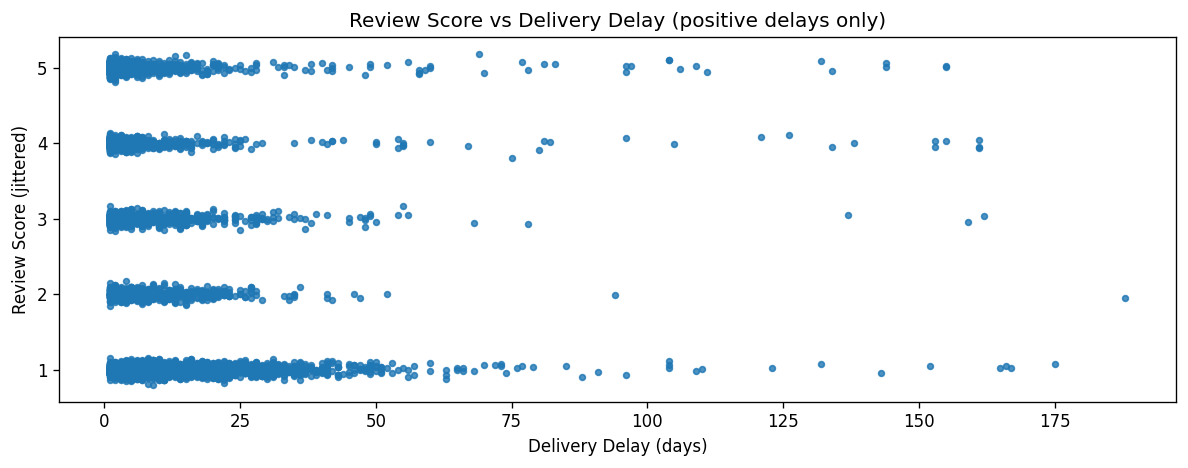

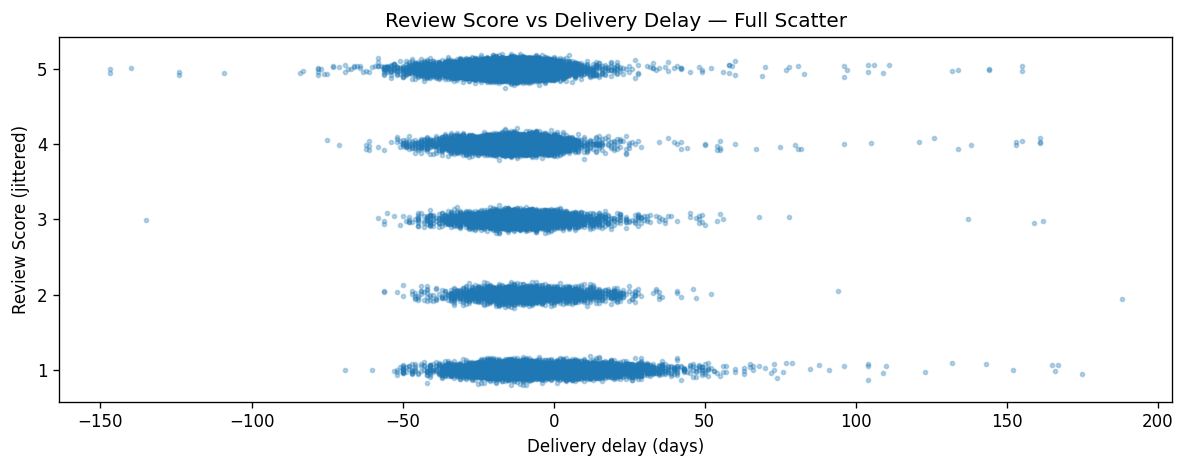

In [15]:

positive_delays = eda_df[eda_df['delivery_delay_days'] > 0].copy()
plt.figure(figsize=(10,4))
jittered_score = positive_delays['review_score'] + np.random.normal(0, 0.05, len(positive_delays))
plt.scatter(positive_delays['delivery_delay_days'], jittered_score, s=12, alpha=0.8)
plt.xlabel("Delivery Delay (days)"); plt.ylabel("Review Score (jittered)")
plt.title("Review Score vs Delivery Delay (positive delays only)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
jittered_score_full = eda_df['review_score'] + np.random.normal(0, 0.05, len(eda_df))
plt.scatter(eda_df['delivery_delay_days'], jittered_score_full, s=6, alpha=0.3)
plt.xlabel("Delivery delay (days)"); plt.ylabel("Review Score (jittered)")
plt.title("Review Score vs Delivery Delay — Full Scatter")
plt.tight_layout(); plt.show()


### (Restored) Average Review Score & Counts by Delivery Delay Bins

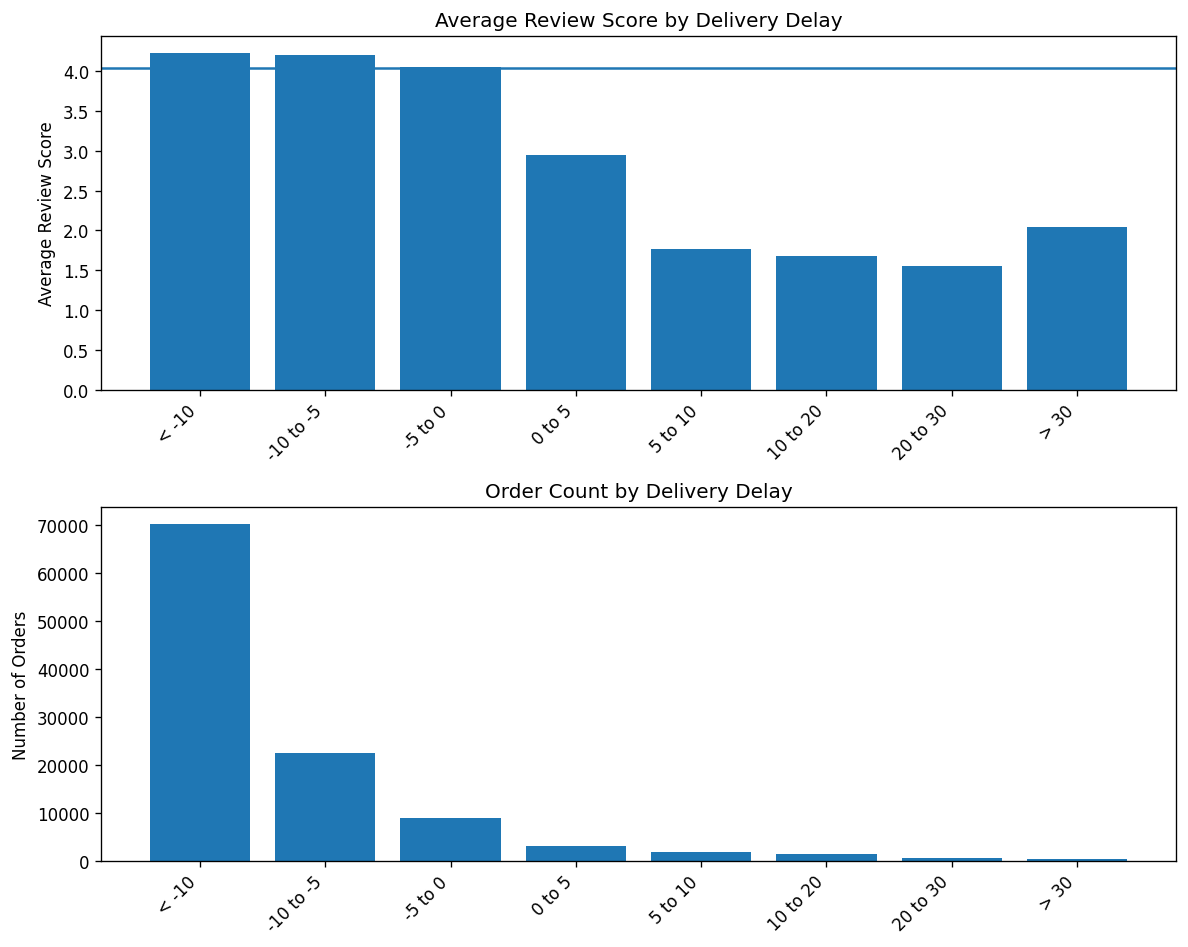

,delay_bin,avg_review_score,count
0,< -10,4.230906,70180
1,-10 to -5,4.200418,22483
2,-5 to 0,4.056148,8816
3,0 to 5,2.949934,3016
4,5 to 10,1.769490,1783
5,10 to 20,1.678494,1381
6,20 to 30,1.551797,473
7,> 30,2.043353,346


In [16]:

bins = [-np.inf, -10, -5, 0, 5, 10, 20, 30, np.inf]
labels = ['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '20 to 30', '> 30']
eda_df['delay_bin'] = pd.cut(eda_df['delivery_delay_days'], bins=bins, labels=labels)

delay_review = (eda_df.groupby('delay_bin', observed=True)['review_score']
                .agg(['mean','count']).reset_index().rename(columns={'mean':'avg_review_score'}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8))
ax1.bar(range(len(delay_review)), delay_review['avg_review_score'])
ax1.set_xticks(range(len(delay_review))); ax1.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax1.set_ylabel('Average Review Score'); ax1.set_title('Average Review Score by Delivery Delay')
ax1.axhline(y=eda_df['review_score'].mean())

ax2.bar(range(len(delay_review)), delay_review['count'])
ax2.set_xticks(range(len(delay_review))); ax2.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax2.set_ylabel('Number of Orders'); ax2.set_title('Order Count by Delivery Delay')
plt.tight_layout(); plt.show()

delay_review


### (Restored) Sentiment Prediction Accuracy by Order Status

,order_status,is_correct
6,unavailable,1.000000
4,processing,0.903614
3,invoiced,0.833333
2,delivered,0.796182
1,canceled,0.772727
5,shipped,0.692982
0,approved,0.000000


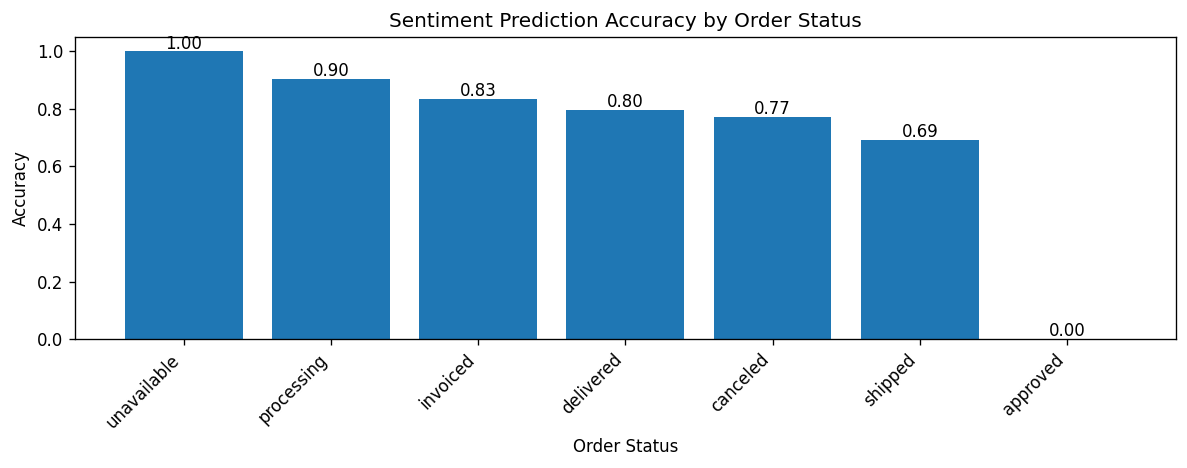

In [17]:

probs = trained['model'].predict(trained['X_test_t'], verbose=0)
y_pred_idx = probs.argmax(axis=1)
y_true_idx = trained['y_test'].codes
target_classes = trained['target_classes']
X_test = trained['X_test']

pred_names = [target_classes[i] for i in y_pred_idx]
true_names = [target_classes[i] for i in y_true_idx]
analysis_df = pd.DataFrame({
    'order_status': X_test['order_status'].values,
    'true_sentiment': true_names,
    'predicted_sentiment': pred_names
})
analysis_df['is_correct'] = (analysis_df['true_sentiment'] == analysis_df['predicted_sentiment'])

acc_by_status = analysis_df.groupby('order_status')['is_correct'].mean().reset_index()
acc_by_status = acc_by_status.sort_values('is_correct', ascending=False)
display(acc_by_status)

plt.figure(figsize=(10,4))
plt.bar(range(len(acc_by_status)), acc_by_status['is_correct'])
plt.xticks(range(len(acc_by_status)), acc_by_status['order_status'], rotation=45, ha='right')
plt.title('Sentiment Prediction Accuracy by Order Status'); plt.xlabel('Order Status'); plt.ylabel('Accuracy')
for i, v in enumerate(acc_by_status['is_correct']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.ylim(0, 1.05); plt.tight_layout(); plt.show()


## 10) SHAP Explanations (DeepExplainer for Keras, with fallback)

In [18]:

import shap
shap.initjs()

preprocess = trained['preprocess']
model = trained['model']
X_train_t = trained['X_train_t']
X_test_t  = trained['X_test_t']
target_classes = trained['target_classes']

# Feature names
try:
    feature_names = preprocess.get_feature_names_out().tolist()
except Exception:
    feature_names = []
    feature_names += [f"num__{c}" for c in ['product_description_lenght','product_photos_qty','price','freight_value','delivery_delay_days']]
    ohe = preprocess.named_transformers_['ohe_low']
    feature_names += [f"ohe_low__{n}" for n in ohe.get_feature_names_out(['order_status']).tolist()]
    feature_names += ['target_high__product_category_name']
    feature_names += ['region_label__customer_region']

# Background and subset
bg_n = min(800, X_train_t.shape[0])
te_n = min(200, X_test_t.shape[0])
X_train_sampled_shap = X_train_t[:bg_n].astype('float32')
X_test_subset_shap   = X_test_t[:te_n].astype('float32')

# Try DeepExplainer; fallback to model-agnostic Explainer
try:
    explainer = shap.DeepExplainer(model, X_train_sampled_shap)
    sv_list = explainer.shap_values(X_test_subset_shap)  # list per class
    shap_values = np.stack(sv_list, axis=-1)             # (n, p, K)
except Exception as e:
    print("DeepExplainer fallback:", e)
    explainer = shap.Explainer(model, X_train_sampled_shap)
    shap_exp = explainer(X_test_subset_shap)
    shap_values = shap_exp.values  # (n, p, K)

print("SHAP values shape:", shap_values.shape)
feature_names_aligned = feature_names[:shap_values.shape[1]]


SHAP values shape: (14, 3, 200)


=== Class: Negative ===


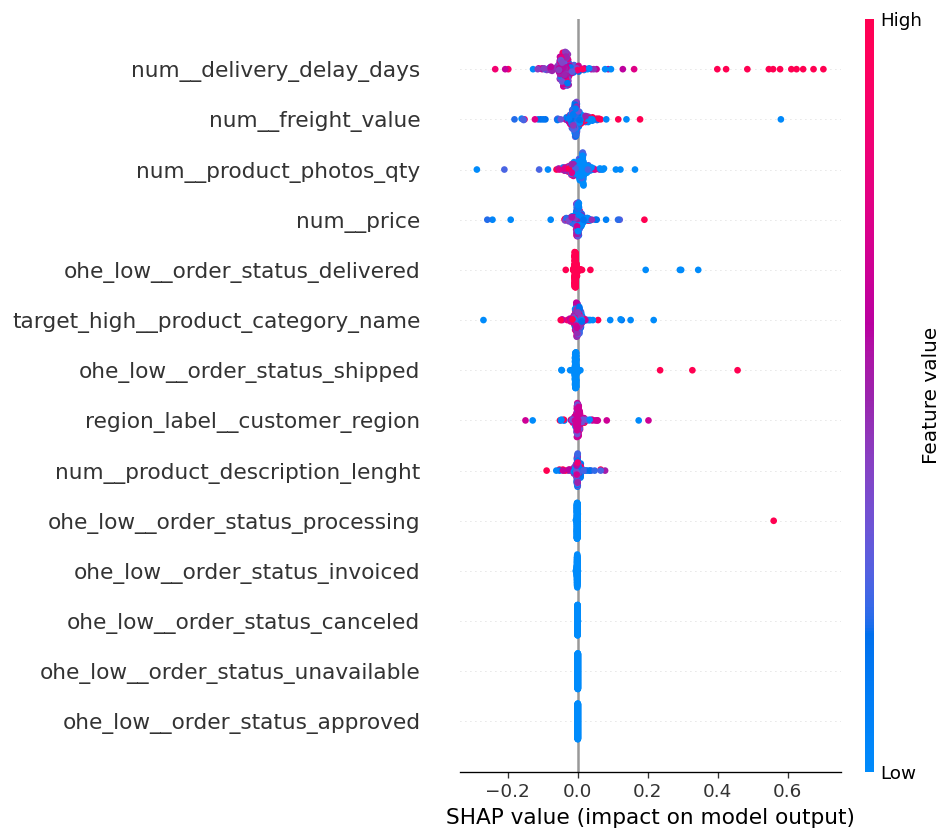

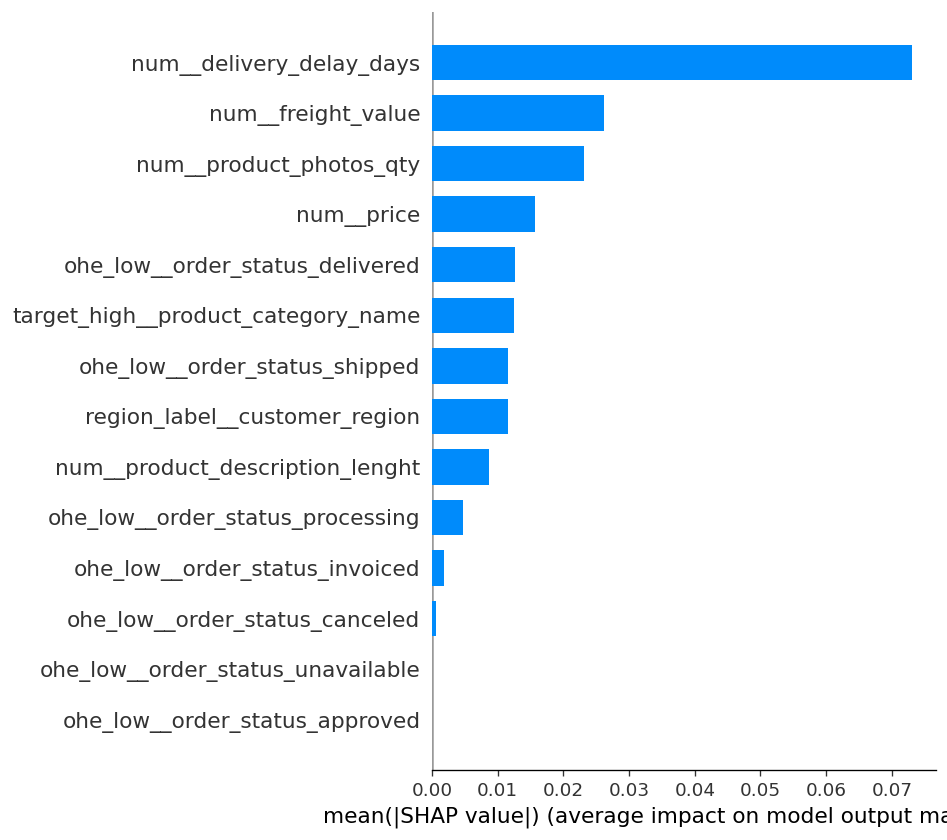

=== Class: Neutral ===


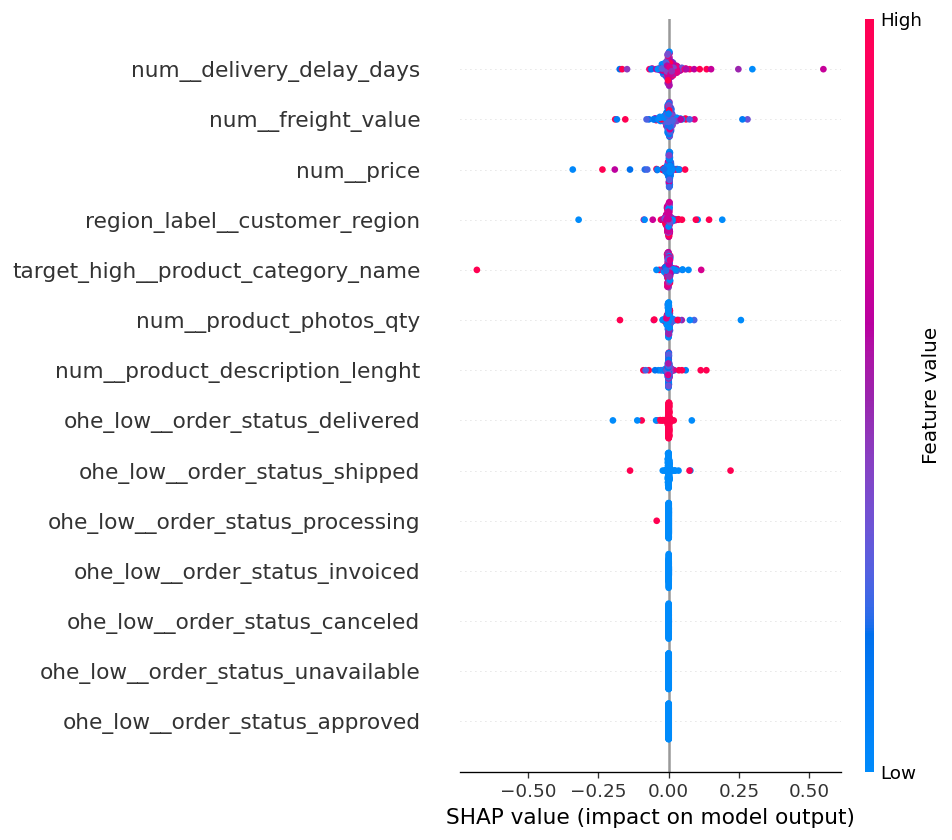

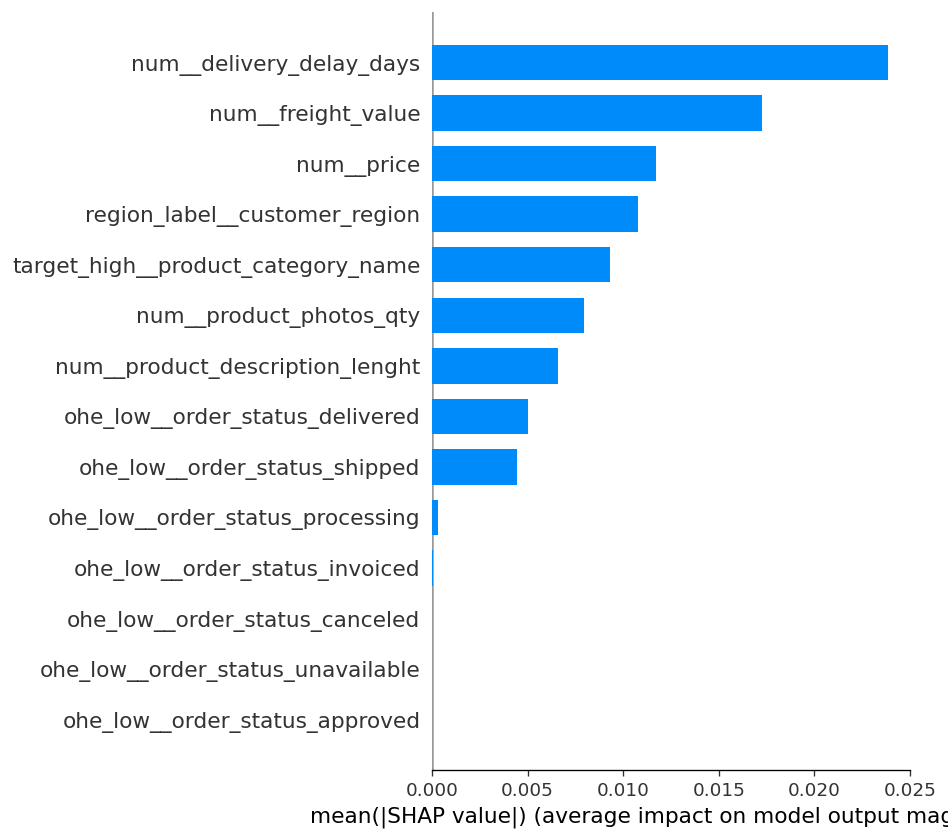

=== Class: Positive ===


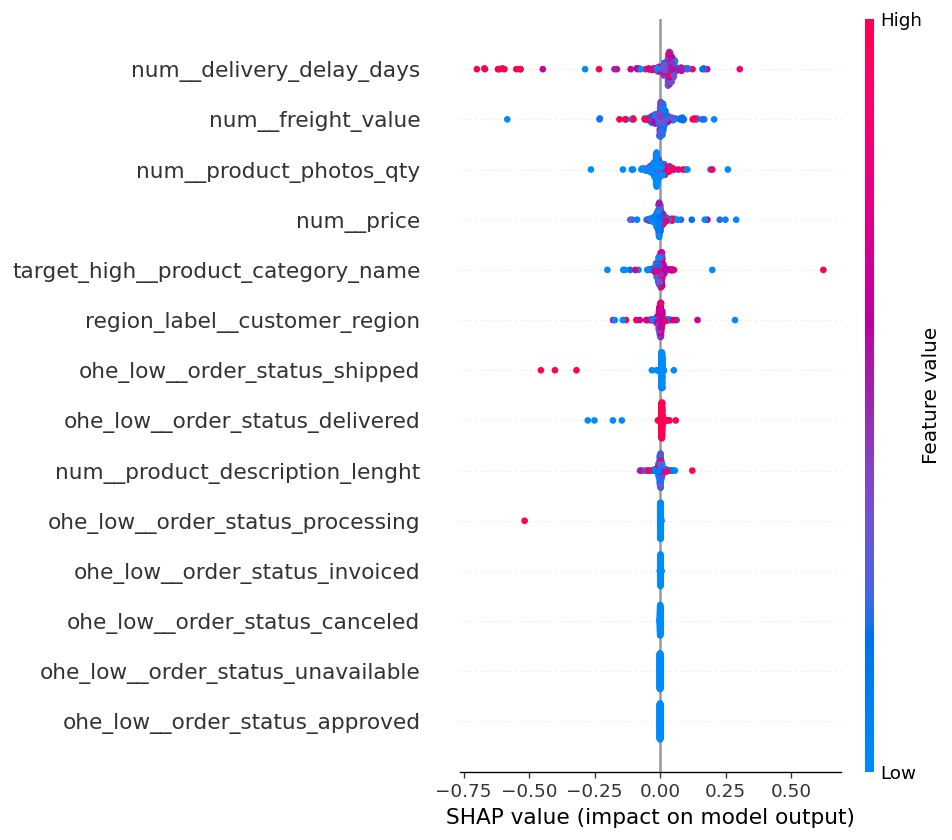

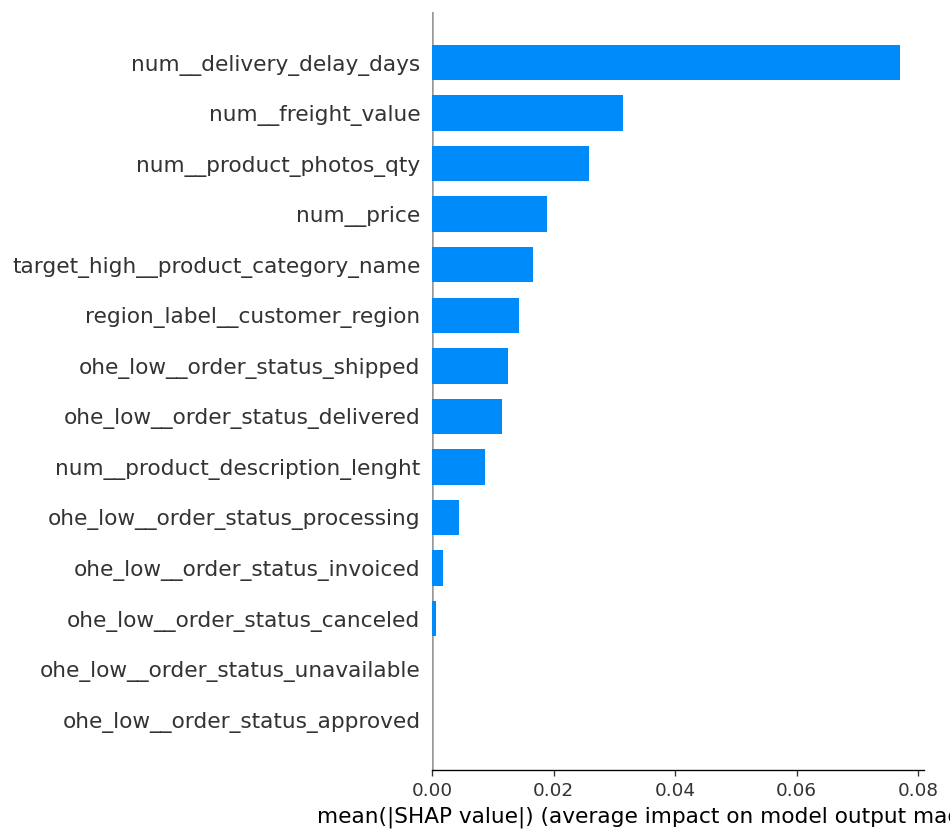

,feature,mean_abs_shap
0,num__delivery_delay_days,0.057973
1,num__freight_value,0.025000
2,num__product_photos_qty,0.018953
3,num__price,0.015454
4,target_high__product_category_name,0.012793
5,region_label__customer_region,0.012207
6,ohe_low__order_status_delivered,0.009734
7,ohe_low__order_status_shipped,0.009514
8,num__product_description_lenght,0.007996
9,ohe_low__order_status_processing,0.003134


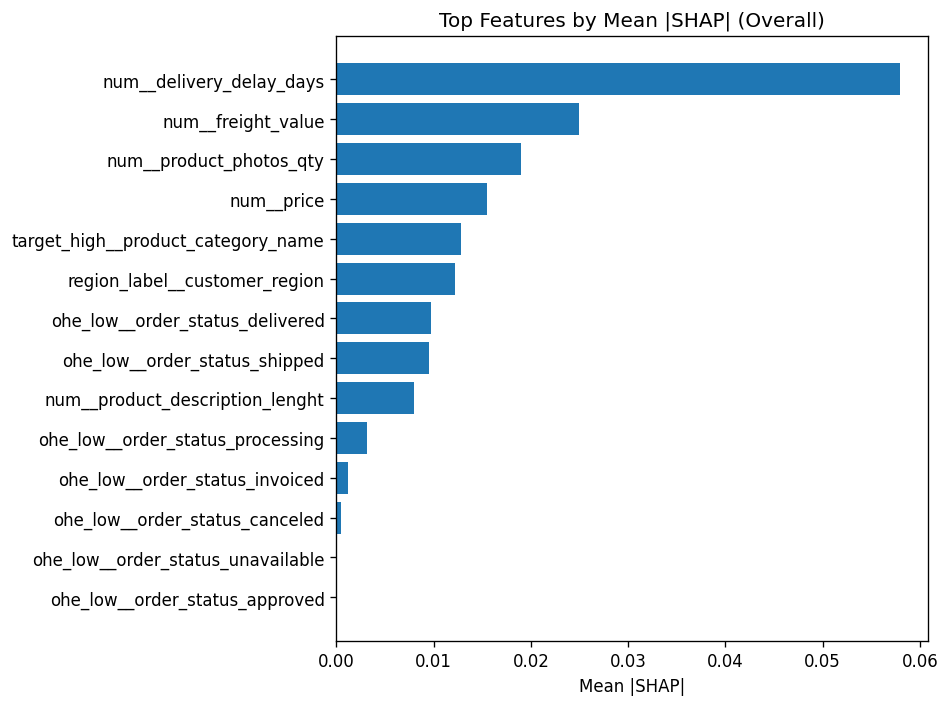

In [22]:
# === Full SHAP block: feature names + compute (if needed) + normalize + plot ALL features per class ===
import numpy as np, shap
from tensorflow import keras

# 0) Ensure we have trained objects and test subset
try:
    trained
except NameError:
    trained = train_pipeline(mergeddf, test_size=0.2, random_state=42)

preprocess = trained['preprocess']
model      = trained['model']
X_train_t  = trained['X_train_t']
X_test_t   = trained['X_test_t']
target_classes = trained['target_classes']

# 1) Build proper feature names from the fitted ColumnTransformer
try:
    feature_names_aligned = preprocess.get_feature_names_out().tolist()
except Exception:
    feature_names_aligned = []
    # numeric block
    feature_names_aligned += [f"num__{c}" for c in ['product_description_lenght','product_photos_qty','price','freight_value','delivery_delay_days']]
    # one-hot block
    ohe = preprocess.named_transformers_['ohe_low']
    feature_names_aligned += [f"ohe_low__{n}" for n in ohe.get_feature_names_out(['order_status']).tolist()]
    # target-encoded category
    feature_names_aligned += ['target_high__product_category_name']
    # region label
    feature_names_aligned += ['region_label__customer_region']

# 2) Pick background + test subset for SHAP
bg_n = min(800, X_train_t.shape[0])
te_n = min(200, X_test_t.shape[0])
X_bg   = X_train_t[:bg_n].astype('float32')
X_show = X_test_t[:te_n].astype('float32')

# 3) Compute SHAP values if not already present
try:
    shap_values  # noqa: F821
except NameError:
    # Prefer DeepExplainer on logits (pre-softmax) for cleaner multi-class SHAP
    # Clone model and set last activation to linear
    logit_model = keras.models.clone_model(model)
    logit_model.set_weights(model.get_weights())
    try:
        logit_model.layers[-1].activation = keras.activations.linear
    except Exception:
        pass  # if layer doesn't expose activation, it's fine to proceed with original model

    try:
        explainer = shap.DeepExplainer(logit_model, X_bg)
        sv_list = explainer.shap_values(X_show)     # list of (n, p) per class
        shap_values = np.stack(sv_list, axis=-1)    # (n, p, K)
    except Exception as e:
        print("DeepExplainer failed, falling back to shap.Explainer:", e)
        explainer = shap.Explainer(logit_model, X_bg)
        exp = explainer(X_show)                     # Explanation
        # exp.values may be (n,p) for binary or (n,p,K) for multiclass
        vals = np.asarray(exp.values)
        shap_values = vals[..., None] if vals.ndim == 2 else vals

# 4) Utility: normalize any SHAP format to (n_samples, n_features, n_classes)
def to_sv3(shap_values, X):
    n, p = X.shape

    if isinstance(shap_values, list):  # list of per-class (n,p)
        ns = min(arr.shape[0] for arr in shap_values)
        ps = min(arr.shape[1] for arr in shap_values)
        return np.stack([arr[:ns, :ps] for arr in shap_values], axis=-1)  # (n,p,K)

    if hasattr(shap_values, "values"):
        arr = np.asarray(shap_values.values)
    else:
        arr = np.asarray(shap_values)

    if arr.ndim == 2:       # (n,p) -> (n,p,1)
        # handle transposed (p,n)
        if arr.shape == (p, n):
            arr = arr.T
        return arr[..., None]

    if arr.ndim == 3:
        a, b, c = arr.shape
        # already (n,p,K)
        if a == n and b == p:
            return arr
        # common case: (p,K,n) -> (n,p,K)
        if a == p and c == n:
            return np.transpose(arr, (2, 0, 1))
        # or (n,K,p) -> (n,p,K)
        if a == n and c == p:
            return np.transpose(arr, (0, 2, 1))
        # brute-force try perms
        for perm in [(0,1,2),(0,2,1),(1,0,2),(1,2,0),(2,0,1),(2,1,0)]:
            cand = np.transpose(arr, perm)
            if cand.shape[0] == n and cand.shape[1] == p:
                return cand
        raise ValueError(f"Could not align SHAP tensor {arr.shape} to (n={n}, p={p}, K)")
    raise ValueError(f"Unsupported SHAP type/shape: {type(shap_values)}, {getattr(shap_values, 'shape', None)}")

# 5) Normalize & align names
sv3 = to_sv3(shap_values, X_show)         # -> (n, p, K)
n, p, k = sv3.shape
feature_names = feature_names_aligned[:p]
if len(feature_names) < p:
    feature_names += [f"feature_{i}" for i in range(len(feature_names), p)]

# 6) Plot ALL features per class (beeswarm + bar)
classes_plot = list(target_classes)[:k]
for i, name in enumerate(classes_plot):
    print(f"=== Class: {name} ===")
    shap.summary_plot(
        sv3[:, :, i],
        X_show[:, :p],
        feature_names=feature_names,
        max_display=p,
        show=True
    )
    shap.summary_plot(
        sv3[:, :, i],
        X_show[:, :p],
        feature_names=feature_names,
        plot_type='bar',
        max_display=p,
        show=True
    )

# 7) (Optional) Print a top-features table overall and per-class
import pandas as pd, matplotlib.pyplot as plt
mean_abs_overall = np.mean(np.abs(sv3), axis=(0,2))  # (p,)
order = np.argsort(mean_abs_overall)[::-1]
top_overall = pd.DataFrame({"feature": np.array(feature_names)[order], "mean_abs_shap": mean_abs_overall[order]})
display(top_overall.head(20))

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[order][:20][::-1], mean_abs_overall[order][:20][::-1])
plt.title("Top Features by Mean |SHAP| (Overall)")
plt.xlabel("Mean |SHAP|")
plt.tight_layout(); plt.show()


In [23]:
print(shap_values.shape)

(14, 3, 200)


In [24]:
def predict_sentiment(new_rows, trained):
    """
    Predict sentiment for 1+ new rows using the fitted pipeline.

    Parameters
    ----------
    new_rows : pd.DataFrame or dict
        Should contain (some/all) of:
        - NUM_COLS: 'product_description_lenght','product_photos_qty','price','freight_value'
        - 'delivery_delay' (Timedelta) OR 'delivery_delay_days' (numeric)
        - 'order_status', 'product_category_name', 'customer_state' (or 'customer_region')

    trained : dict
        The object returned by train_pipeline(...)

    Returns
    -------
    pd.DataFrame with columns:
        ['predicted'] + [f'proba_{c}' for c in target_classes]
    """
    import pandas as pd
    import numpy as np

    preprocess = trained['preprocess']
    model      = trained['model']
    X_train    = trained['X_train']
    target_classes = trained['target_classes']

    # Accept dict or DataFrame
    if isinstance(new_rows, dict):
        df = pd.DataFrame([new_rows]).copy()
    else:
        df = new_rows.copy()

    # ---- Ensure/derive required fields ----
    # delivery_delay_days
    if 'delivery_delay_days' not in df.columns:
        if 'delivery_delay' in df.columns:
            # If not already timedelta, try to coerce
            if not np.issubdtype(df['delivery_delay'].dtype, np.timedelta64):
                try:
                    df['delivery_delay'] = pd.to_timedelta(df['delivery_delay'])
                except Exception:
                    df['delivery_delay'] = pd.NaT
            df['delivery_delay_days'] = df['delivery_delay'].dt.days
        else:
            df['delivery_delay_days'] = np.nan

    # customer_region
    if 'customer_region' not in df.columns:
        if 'customer_state' in df.columns:
            df['customer_region'] = df['customer_state'].map(map_state_to_region)
        else:
            df['customer_region'] = np.nan

    # Make sure all expected columns exist (even if NaN)
    required_num = ['product_description_lenght','product_photos_qty','price','freight_value','delivery_delay_days']
    required_cat = ['order_status','product_category_name','customer_region']
    for col in required_num + required_cat:
        if col not in df.columns:
            df[col] = np.nan

    # ---- Impute using training medians & region fallback (no leakage; medians from pre-features) ----
    med = X_train[required_num].median(numeric_only=True).to_dict()
    df[required_num] = df[required_num].apply(pd.to_numeric, errors='coerce')
    for c in required_num:
        fill = 0 if pd.isna(med.get(c)) else med[c]
        df[c] = df[c].fillna(fill)

    # region fallback = most common region in training
    region_fallback = X_train['customer_region'].mode(dropna=True)
    region_fallback = region_fallback.iloc[0] if len(region_fallback) else 'Southeast'
    df['customer_region'] = df['customer_region'].fillna(region_fallback)
    # guard: if anything not in REGION_ORDER, fallback
    df.loc[~df['customer_region'].isin(REGION_ORDER), 'customer_region'] = region_fallback

    # ---- Reduce to the *exact* feature set used in training (same order) ----
    keep = ['product_description_lenght','product_photos_qty','price','freight_value',
            'delivery_delay_days','order_status','product_category_name','customer_region']
    X_infer = df[keep].copy()

    # ---- Transform and predict ----
    X_t = preprocess.transform(X_infer)
    probs = model.predict(X_t, verbose=0)

    idx = probs.argmax(axis=1)
    labels = [target_classes[i] for i in idx]

    out = pd.DataFrame({'predicted': labels})
    for j, cls in enumerate(target_classes):
        out[f'proba_{cls}'] = probs[:, j].astype(float)
    return out


In [33]:
dummy_new_review_full = {
    'order_id': 'dummy_order_id_123',
    'order_item_id': 1,
    'product_id': 'dummy_product_id_123',
    'seller_id': 'dummy_seller_id_123',
    'shipping_limit_date': pd.to_datetime('2023-05-15 10:00:00'),

    # ---- features we actually use ----
    'price': 89.90,
    'freight_value': 15.50,
    'product_category_name': 'beleza_saude',
    'product_name_lenght': 50.0,                 # not used by the model
    'product_description_lenght': 150.0,         # used
    'product_photos_qty': 20.0,                  # used

    # extra product dims (not used by the model)
    'product_weight_g': 500.0,
    'product_length_cm': 30.0,
    'product_height_cm': 10.0,
    'product_width_cm': 20.0,

    'customer_id': 'dummy_customer_id_123',
    'order_status': 'delivered',                 # used
    'order_purchase_timestamp': pd.to_datetime('2023-05-01 10:00:00'),
    'order_approved_at': pd.to_datetime('2023-05-01 10:30:00'),
    'order_delivered_carrier_date': pd.to_datetime('2023-05-05 10:00:00'),
    'order_delivered_customer_date': pd.to_datetime('2023-05-06 10:00:00'),
    'order_estimated_delivery_date': pd.to_datetime('2023-05-16 10:00:00'),

    # delivery delay (negative because delivered early) — used via delivery_delay_days
    'delivery_delay': pd.to_datetime('2023-05-06 10:00:00') - pd.to_datetime('2023-05-16 10:00:00'),

    'customer_unique_id': 'dummy_unique_id_123',
    'customer_zip_code_prefix': 12345,
    'customer_city': 'sao paulo',
    'customer_state': 'SP',                      # used (to derive region)

    'review_id': 'dummy_review_id_123',
    'review_creation_date': pd.to_datetime('2023-05-07 10:00:00'),
    'review_answer_timestamp': pd.to_datetime('2023-05-07 11:00:00'),
}

# Run the prediction on the dummy row (one row DataFrame is fine)
dummy_df = pd.DataFrame([dummy_new_review_full])
pred = predict_sentiment(dummy_df, trained)
pred


,predicted,proba_Negative,proba_Neutral,proba_Positive
0,Positive,0.072768,0.020777,0.906455
